# DAT-SPECT vs MDS-UPDRS Part III — Contralateral Within-Subject Analysis
**Pipeline:** SAA+ stratification → dominant side at baseline → less-affected putamen SBR vs contralateral motor score → LMM (random slope)

---
## Step 0 — Imports and paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats as scipy_stats
import warnings, os, io
warnings.filterwarnings('ignore')

BASE = os.path.join('..', '..', '04_Data', 'Raw')
OUT  = os.path.join('..', '..', '04_Data', 'Results', 'results_datscan_v3')
os.makedirs(OUT, exist_ok=True)


print("Ready.")

Ready.


---
## Step 1 — SAA+ Biological Stratification
Same approach as NfL analysis: keep only PD patients who are SAA positive. This ensures all patients share the same underlying α-synuclein pathology.

In [2]:
bio = pd.read_csv(BASE + r'\Current_Biospecimen_Analysis_Results_21May2026.csv', low_memory=False)
pd_patnos_all = bio[bio['COHORT'] == 'PD']['PATNO'].unique()

# Parse SAA (xlsx disguised as csv)
raw_xls  = pd.read_excel(BASE + r'\SAA_Biospecimen_Analysis_Results_21May2026.csv')
col_name = raw_xls.columns[0]
all_lines = col_name + '\n' + '\n'.join(raw_xls.iloc[:, 0].astype(str).tolist())
saa_raw  = pd.read_csv(io.StringIO(all_lines), skipinitialspace=True)

saa_pd = saa_raw[saa_raw['COHORT'] == 'PD']
saa_status = saa_pd.groupby('PATNO')['SAA_Status'].apply(
    lambda x: 'Positive' if (x == 'Positive').any() else 'Negative'
).reset_index()
saa_status.columns = ['PATNO', 'SAA_overall']

n_pos = (saa_status['SAA_overall'] == 'Positive').sum()
n_neg = (saa_status['SAA_overall'] == 'Negative').sum()

print(f"PD patients total: {len(pd_patnos_all)}")
print(f"  SAA+ : {n_pos} ({n_pos/(n_pos+n_neg)*100:.1f}%) — kept")
print(f"  SAA- : {n_neg} ({n_neg/(n_pos+n_neg)*100:.1f}%) — excluded")

saa_pos_patnos = saa_status[saa_status['SAA_overall'] == 'Positive']['PATNO'].unique()

PD patients total: 1145
  SAA+ : 1154 (88.7%) — kept
  SAA- : 147 (11.3%) — excluded


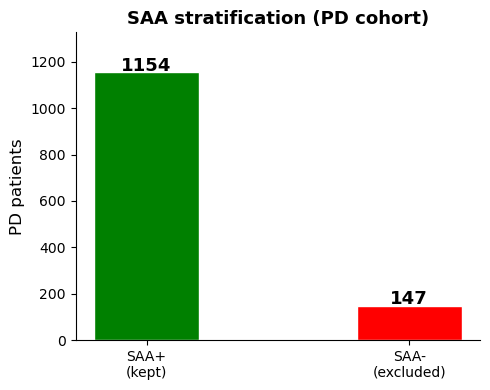

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['SAA+\n(kept)', 'SAA-\n(excluded)'], [n_pos, n_neg],
       color=['green', 'red'], edgecolor='white', width=0.4)
for i, v in enumerate([n_pos, n_neg]):
    ax.text(i, v + 8, str(v), ha='center', fontsize=13, fontweight='bold')
ax.set_ylabel('PD patients', fontsize=12)
ax.set_title('SAA stratification (PD cohort)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(n_pos, n_neg) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig(f'{OUT}/DaT_Fig_SAA_stratification.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 2 — Load DaTscan (left + right) and UPDRS lateralized scores
- **DaTscan:** left and right putamen SBR separately (PUTAMEN_L_REF_CWM, PUTAMEN_R_REF_CWM)
- **UPDRS:** 8 lateralized motor items per side (rigidity, finger tapping, hand movements, pronation-supination, toe tapping, leg agility, postural tremor, kinetic tremor)
- **Filter:** OFF state only, SAA+ patients, ≥3 matched visits

In [4]:
dat = pd.read_csv(BASE + r'\Xing_Core_Lab_-_Quant_SBR_24May2026.csv', low_memory=False)
dat = dat[dat['PATNO'].isin(saa_pos_patnos)].copy()
for c in ['PUTAMEN_L_REF_CWM', 'PUTAMEN_R_REF_CWM']:
    dat[c] = pd.to_numeric(dat[c], errors='coerce')
dat = dat.dropna(subset=['PUTAMEN_L_REF_CWM', 'PUTAMEN_R_REF_CWM'])
dat = dat[['PATNO','EVENT_ID','PUTAMEN_L_REF_CWM','PUTAMEN_R_REF_CWM']]
print(f"DaTscan (SAA+, L+R): {len(dat)} rows, {dat['PATNO'].nunique()} patients")

upd = pd.read_csv(BASE + r'\MDS-UPDRS_Part_III_21May2026.csv', low_memory=False)
upd['EXAMDT'] = pd.to_datetime(upd['EXAMDT'], format='%m/%Y', errors='coerce')

LAT_R = ['NP3RIGRL','NP3FTAPR','NP3HMOVR','NP3PRSPR','NP3TTAPR','NP3LGAGR','NP3PTRMR','NP3KTRMR']
LAT_L = ['NP3RIGLL','NP3FTAPL','NP3HMOVL','NP3PRSPL','NP3TTAPL','NP3LGAGL','NP3PTRML','NP3KTRML']
for c in LAT_R + LAT_L:
    upd[c] = pd.to_numeric(upd[c], errors='coerce')
    
upd['MOTOR_R'] = upd[LAT_R].sum(axis=1, min_count=4)
upd['MOTOR_L'] = upd[LAT_L].sum(axis=1, min_count=4)
upd = upd.dropna(subset=['MOTOR_R','MOTOR_L'])

mask = (upd['PDSTATE'] == 'OFF') | (upd['PDSTATE'].isna() & (upd['PDMEDYN'] != 1))
upd_off = upd[mask].drop_duplicates(['PATNO','EVENT_ID'])
print(f"UPDRS OFF with lateral scores: {len(upd_off)} rows")

df = dat.merge(upd_off[['PATNO','EVENT_ID','EXAMDT','MOTOR_R','MOTOR_L']], on=['PATNO','EVENT_ID'])
df = df.dropna(subset=['PUTAMEN_L_REF_CWM','PUTAMEN_R_REF_CWM','MOTOR_R','MOTOR_L','EXAMDT'])

vpp = df.groupby('PATNO').size()
dfd = df[df['PATNO'].isin(vpp[vpp >= 3].index)].sort_values(['PATNO','EXAMDT']).copy()
print(f"\nFinal dataset: {dfd['PATNO'].nunique()} patients, {len(dfd)} visits (>=3 visits each)")

age_df = pd.read_csv(BASE + r'\Age_at_visit_16Jun2026.csv', low_memory=False)

sex_df = bio[['PATNO','SEX']].drop_duplicates(subset='PATNO')
sex_map = {'Male':1,'Female':0,'male':1,'female':0}
sex_df = sex_df.copy()
sex_df['SEX_bin'] = sex_df['SEX'].map(sex_map)

print('Age and sex loaded.')

DaTscan (SAA+, L+R): 2704 rows, 921 patients
UPDRS OFF with lateral scores: 26565 rows

Final dataset: 242 patients, 852 visits (>=3 visits each)
Age and sex loaded.


---
## Step 3 — Determine dominant (more affected) side at baseline
At the first visit, compare the right vs left motor score.
The side with the **higher motor score** is the more clinically affected side.

Since motor control is contralateral:
- More affected body = **Right** → more depleted putamen = **Left** → track **Right putamen SBR vs Left motor score**
- More affected body = **Left** → more depleted putamen = **Right** → track **Left putamen SBR vs Right motor score**

In [5]:
# Baseline visit = first EXAMDT per patient
baseline = dfd.sort_values('EXAMDT').groupby('PATNO').first().reset_index()

# Dominant side: which body side has higher motor score at baseline?
baseline['dominant_body'] = np.where(baseline['MOTOR_R'] >= baseline['MOTOR_L'], 'Right', 'Left')

# The LESS affected side (what we will track):
# If dominant body = Right → less affected body = Left → less affected putamen = Right (contralateral)
# If dominant body = Left  → less affected body = Right → less affected putamen = Left (contralateral)
baseline['track_putamen'] = np.where(baseline['dominant_body'] == 'Right', 'R', 'L')
baseline['track_motor']   = np.where(baseline['dominant_body'] == 'Right', 'MOTOR_L', 'MOTOR_R')

side_counts = baseline['dominant_body'].value_counts()
print("Dominant (more affected) side at baseline:")
print(f"  Right body more affected: {side_counts.get('Right', 0)} patients")
print(f"  Left  body more affected: {side_counts.get('Left',  0)} patients")
print()
print("These patients will be tracked on their LESS affected side:")
print(f"  Track Right putamen + Left motor  : {(baseline['track_putamen']=='R').sum()} patients")
print(f"  Track Left  putamen + Right motor : {(baseline['track_putamen']=='L').sum()} patients")

Dominant (more affected) side at baseline:
  Right body more affected: 131 patients
  Left  body more affected: 111 patients

These patients will be tracked on their LESS affected side:
  Track Right putamen + Left motor  : 131 patients
  Track Left  putamen + Right motor : 111 patients


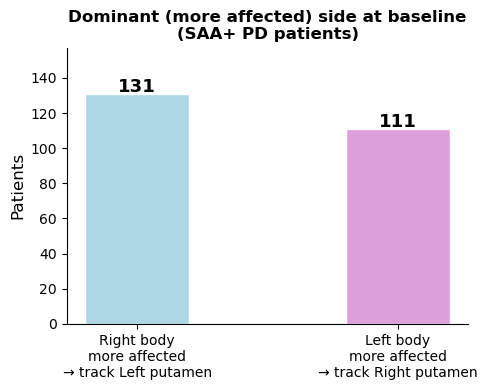

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Right body\nmore affected\n→ track Left putamen',
        'Left body\nmore affected\n→ track Right putamen'],
       [side_counts.get('Right',0), side_counts.get('Left',0)],
       color=['lightblue', 'plum'], edgecolor='white', width=0.4)
for i, v in enumerate([side_counts.get('Right',0), side_counts.get('Left',0)]):
    ax.text(i, v + 1, str(v), ha='center', fontsize=13, fontweight='bold')
ax.set_ylabel('Patients', fontsize=12)
ax.set_title('Dominant (more affected) side at baseline\n(SAA+ PD patients)', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(side_counts.values) * 1.2)
sns.despine()
plt.tight_layout()
plt.savefig(f'{OUT}/DaT_Fig_dominant_side.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 4 — Build contralateral tracking pairs
For each patient, assign their less-affected putamen SBR and the corresponding contralateral motor score for every visit.

In [7]:
# Merge dominant side info into full dataset
side_map = baseline[['PATNO','track_putamen','track_motor']].copy()
dfd = dfd.merge(side_map, on='PATNO', how='left')

# Assign SBR and motor score for the less-affected side
def get_sbr(row):
    if row['track_putamen'] == 'L':
        return row['PUTAMEN_L_REF_CWM']
    else:
        return row['PUTAMEN_R_REF_CWM']

def get_motor(row):
    return row[row['track_motor']]

dfd['SBR_less']   = dfd.apply(get_sbr,   axis=1)
dfd['MOTOR_less'] = dfd.apply(get_motor, axis=1)

print(f"Contralateral pairs built:")
print(f"  Patients : {dfd['PATNO'].nunique()}")
print(f"  Visits   : {len(dfd)}")
print(f"  SBR_less  mean: {dfd['SBR_less'].mean():.3f}  SD: {dfd['SBR_less'].std():.3f}")
print(f"  MOTOR_less mean: {dfd['MOTOR_less'].mean():.2f}  SD: {dfd['MOTOR_less'].std():.2f}")

# Merge age and sex into main dataset
dfd = dfd.merge(age_df[['PATNO','EVENT_ID','AGE_AT_VISIT']],
                on=['PATNO','EVENT_ID'], how='left')
dfd = dfd.merge(sex_df[['PATNO','SEX_bin']],
                on='PATNO', how='left')
print(f'Missing AGE_AT_VISIT: {dfd["AGE_AT_VISIT"].isna().sum()}')
print(f'Missing SEX_bin     : {dfd["SEX_bin"].isna().sum()}')

Contralateral pairs built:
  Patients : 242
  Visits   : 852
  SBR_less  mean: 0.700  SD: 0.247
  MOTOR_less mean: 4.10  SD: 5.14
Missing AGE_AT_VISIT: 4
Missing SEX_bin     : 36


---
## Step 5 — Z-score Normalisation
Standardise both the less-affected putamen SBR and the contralateral motor score to z-scores (mean=0, SD=1) so they can be compared on the same scale.

SBR_less  : mean=0.700, SD=0.247
MOTOR_less: mean=4.10, SD=5.13


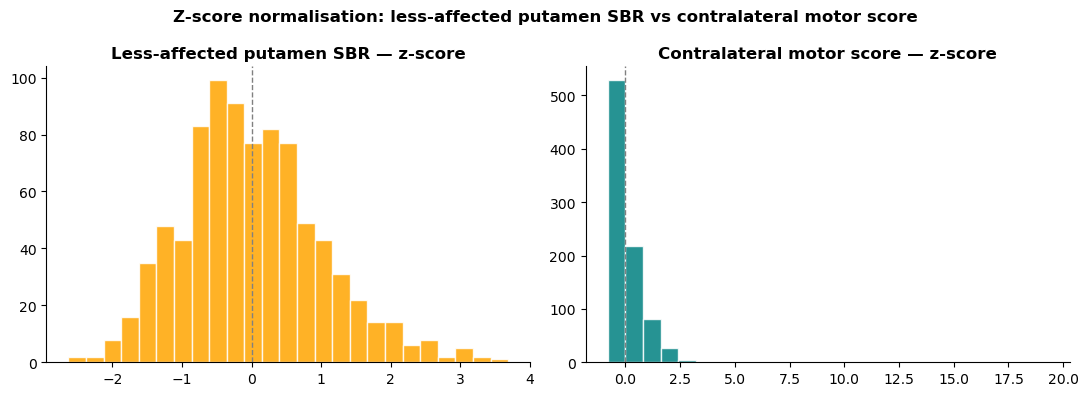

In [8]:
dfd['SBR_z']   = (dfd['SBR_less']   - dfd['SBR_less'].mean())   / dfd['SBR_less'].std()
dfd['MOTOR_z'] = (dfd['MOTOR_less'] - dfd['MOTOR_less'].mean()) / dfd['MOTOR_less'].std()

print(f"SBR_less  : mean={dfd['SBR_less'].mean():.3f}, SD={dfd['SBR_less'].std():.3f}")
print(f"MOTOR_less: mean={dfd['MOTOR_less'].mean():.2f}, SD={dfd['MOTOR_less'].std():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(dfd['SBR_z'],   bins=25, color='orange', edgecolor='white', alpha=0.85)
axes[0].set_title('Less-affected putamen SBR — z-score', fontweight='bold')
axes[0].axvline(0, color='grey', lw=1, linestyle='--')
axes[1].hist(dfd['MOTOR_z'], bins=25, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Contralateral motor score — z-score', fontweight='bold')
axes[1].axvline(0, color='grey', lw=1, linestyle='--')
for ax in axes:
    sns.despine(ax=ax)
plt.suptitle('Z-score normalisation: less-affected putamen SBR vs contralateral motor score',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/DaT_Fig_normalisation.png', dpi=150, bbox_inches='tight')
plt.show()



In [9]:
csv_path_dat = os.path.join(OUT, 'DaTscan_filtered_dataset.csv')
dfd.to_csv(csv_path_dat, index=False)
print(f'Filtered dataset saved:')
print(f'  Path    : {csv_path_dat}')
print(f'  Patients: {dfd["PATNO"].nunique()}')
print(f'  Visits  : {len(dfd)}')
print(f'  Columns : {list(dfd.columns)}')

Filtered dataset saved:
  Path    : ..\..\04_Data\Results\results_datscan_v3\DaTscan_filtered_dataset.csv
  Patients: 242
  Visits  : 860
  Columns : ['PATNO', 'EVENT_ID', 'PUTAMEN_L_REF_CWM', 'PUTAMEN_R_REF_CWM', 'EXAMDT', 'MOTOR_R', 'MOTOR_L', 'track_putamen', 'track_motor', 'SBR_less', 'MOTOR_less', 'AGE_AT_VISIT', 'SEX_bin', 'SBR_z', 'MOTOR_z']


---
## Step 6 — Linear Mixed Effects Model (random slope)
**Formula:** `MOTOR_z ~ SBR_z` with random intercept + random slope per patient.

As dopamine transporters decline (SBR drops), motor symptoms on the contralateral side should worsen (motor score rises) → we expect a **negative** β.

In [10]:
dfd_m = dfd.dropna(subset=['AGE_AT_VISIT', 'SEX_bin', 'SBR_z', 'MOTOR_z']).copy()

model  = smf.mixedlm('MOTOR_z ~ SBR_z + AGE_AT_VISIT + SEX_bin',
                     data=dfd_m,
                     groups=dfd_m['PATNO'].astype(str),
                     re_formula='~SBR_z')
result = model.fit(method='lbfgs')

beta  = result.params['SBR_z']
pval  = result.pvalues['SBR_z']
ci    = result.conf_int()
ci_lo = ci.loc['SBR_z', 0]
ci_hi = ci.loc['SBR_z', 1]

beta_age = result.params['AGE_AT_VISIT']
pval_age = result.pvalues['AGE_AT_VISIT']
beta_sex = result.params['SEX_bin']
pval_sex = result.pvalues['SEX_bin']

print('=' * 60)
print('LMM RESULT — Contralateral (adjusted age+sex, random slope)')
print('=' * 60)
print(f'Patients         : {dfd_m["PATNO"].nunique()}')
print(f'Visits           : {len(dfd_m)}')
print(f'Beta (SBR_z)     : {beta:.4f}')
print(f'95% CI           : [{ci_lo:.3f}, {ci_hi:.3f}]')
print(f'p-value (SBR_z)  : {pval:.4f}')
print(f'Beta (AGE)       : {beta_age:.4f},  p={pval_age:.4f}')
print(f'Beta (SEX)       : {beta_sex:.4f},  p={pval_sex:.4f}')
print(result.summary())

LMM RESULT — Contralateral (adjusted age+sex, random slope)
Patients         : 230
Visits           : 821
Beta (SBR_z)     : -0.2784
95% CI           : [nan, nan]
p-value (SBR_z)  : nan
Beta (AGE)       : 0.0168,  p=0.0000
Beta (SEX)       : -0.0399,  p=nan
           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  MOTOR_z   
No. Observations:   821      Method:              REML      
No. Groups:         230      Scale:               0.6030    
Min. group size:    1        Log-Likelihood:      -1072.1163
Max. group size:    6        Converged:           Yes       
Mean group size:    3.6                                     
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         -1.043    0.241 -4.330 0.000 -1.514 -0.571
SBR_z             -0.278                                    
AGE_AT_VISIT       0.0

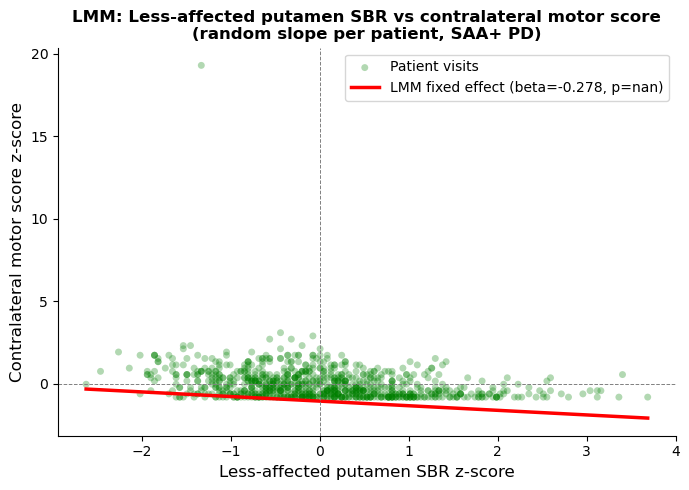

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(dfd['SBR_z'], dfd['MOTOR_z'], alpha=0.3, s=25,
           color='green', edgecolor='none', label='Patient visits')
xs = np.linspace(dfd['SBR_z'].min(), dfd['SBR_z'].max(), 100)
ax.plot(xs, result.params['Intercept'] + beta * xs, color='red', lw=2.5,
        label=f'LMM fixed effect (beta={beta:.3f}, p={pval:.3f})')
ax.axhline(0, color='grey', lw=0.7, linestyle='--')
ax.axvline(0, color='grey', lw=0.7, linestyle='--')
ax.set_xlabel('Less-affected putamen SBR z-score', fontsize=12)
ax.set_ylabel('Contralateral motor score z-score', fontsize=12)
ax.set_title('LMM: Less-affected putamen SBR vs contralateral motor score\n'
             '(random slope per patient, SAA+ PD)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(f'{OUT}/DaT_Fig_LMM.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 7 — Intra-subject temporal profiles
Each panel shows one patient over time. Green = less-affected putamen SBR z-score, Red = contralateral motor score z-score.
When the green line falls and the red rises, it confirms the expected dopaminergic-motor coupling.

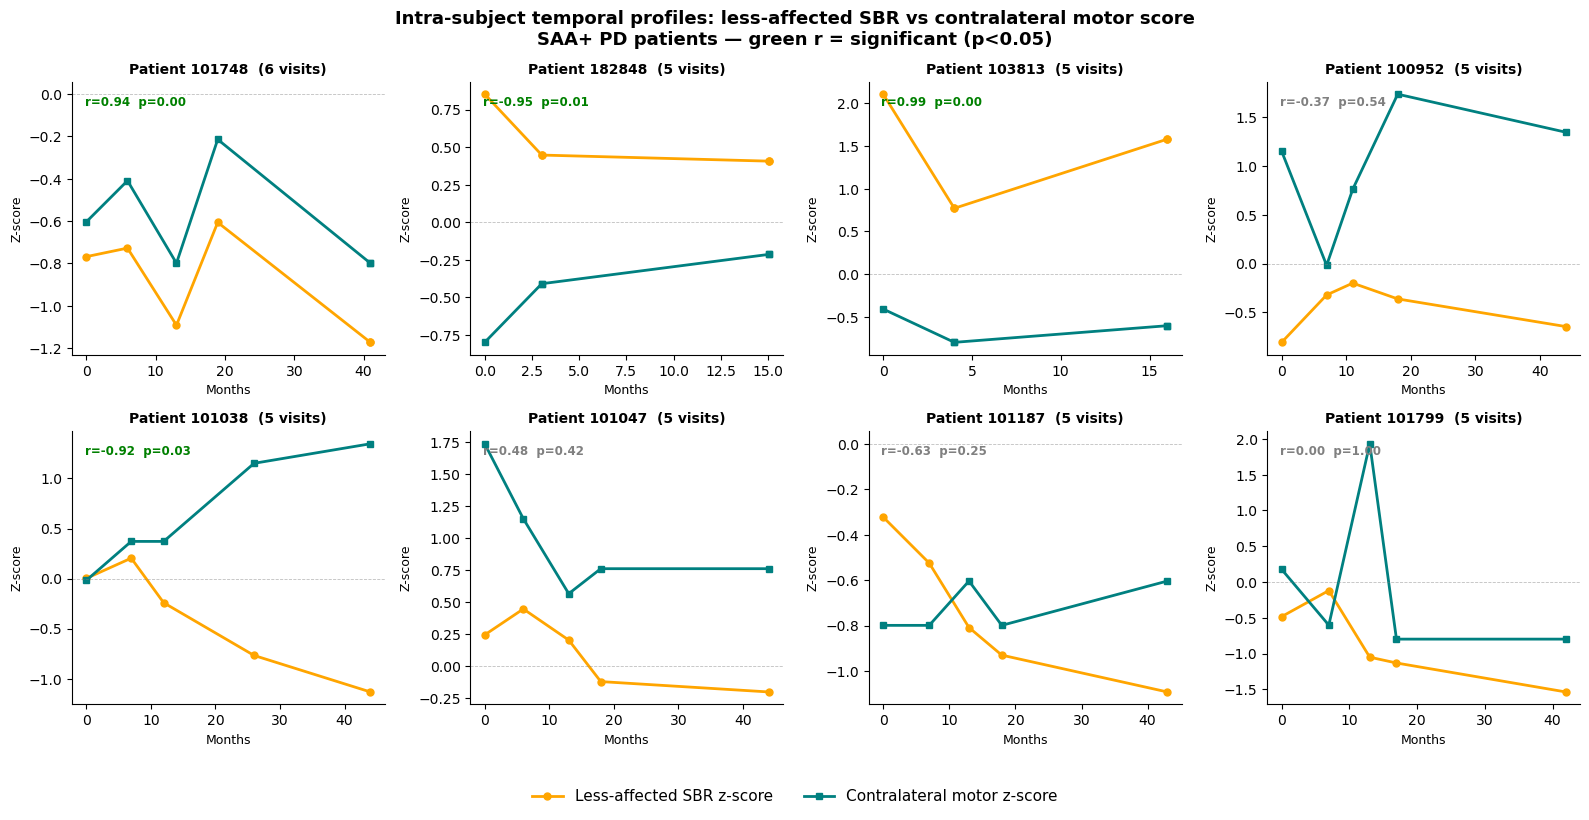

In [12]:
dfd['t_months'] = dfd.groupby('PATNO')['EXAMDT'].transform(
    lambda x: (x - x.min()).dt.days / 30.44)

visit_counts = dfd.groupby('PATNO').size().sort_values(ascending=False)
show_pats = visit_counts.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, pat in zip(axes, show_pats):
    sub = dfd[dfd['PATNO'] == pat].sort_values('t_months')
    t      = sub['t_months'].values
    sbr_z  = sub['SBR_z'].values
    mot_z  = sub['MOTOR_z'].values
    side   = sub['track_putamen'].iloc[0]

    ax.plot(t, sbr_z, color='orange', lw=2, marker='o', ms=5,
            label=f'Putamen {side} SBR z-score')
    ax.plot(t, mot_z, color='teal', lw=2, marker='s', ms=5,
            label='Contralateral motor z-score')
    ax.axhline(0, color='grey', lw=0.6, linestyle='--', alpha=0.5)

    if len(sub) >= 3:
        r, p = scipy_stats.pearsonr(sbr_z, mot_z)
        color_r = 'green' if p < 0.05 else 'gray'
        ax.text(0.04, 0.95, f'r={r:.2f}  p={p:.2f}',
                transform=ax.transAxes, fontsize=8.5, color=color_r,
                va='top', fontweight='bold')

    ax.set_title(f'Patient {pat}  ({len(sub)} visits)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Months', fontsize=9)
    ax.set_ylabel('Z-score', fontsize=9)
    sns.despine(ax=ax)

handles = [
    plt.Line2D([0],[0], color='orange', lw=2, marker='o', ms=5, label='Less-affected SBR z-score'),
    plt.Line2D([0],[0], color='teal', lw=2, marker='s', ms=5, label='Contralateral motor z-score')
]
fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, -0.03), frameon=False)
plt.suptitle('Intra-subject temporal profiles: less-affected SBR vs contralateral motor score\n'
             'SAA+ PD patients — green r = significant (p<0.05)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(f'{OUT}/DaT_Fig_temporal_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 8 — Best and Worst 3 patients
Rank all patients by individual Pearson r between less-affected SBR and contralateral motor score.

In [13]:
records = []
for pat in dfd['PATNO'].unique():
    sub = dfd[dfd['PATNO'] == pat].sort_values('t_months')
    if len(sub) >= 3:
        r, p = scipy_stats.pearsonr(sub['SBR_z'].values, sub['MOTOR_z'].values)
        records.append({'PATNO': pat, 'r': r, 'p': p, 'n': len(sub),
                        'side': sub['track_putamen'].iloc[0]})

corr_df = pd.DataFrame(records).sort_values('r').reset_index(drop=True)
print("Per-patient correlations (ranked, most negative first):")
print(corr_df[['PATNO','r','p','n','side']].to_string(index=False))

# Most negative r = SBR down, motor up (expected direction); tail = weakest coupling
best3  = corr_df.head(3)['PATNO'].tolist()
worst3 = corr_df.tail(3)['PATNO'].tolist()
print(f"\nBest 3  (strongest expected direction, most negative r): {best3}")
print(f"Worst 3 (weakest coupling): {worst3}")

Per-patient correlations (ranked, most negative first):
 PATNO         r        p  n side
116742 -1.000000 0.000000  3    L
  3819 -0.999190 0.025629  3    R
 40555 -0.997609 0.044036  3    R
 50175 -0.997476 0.045238  3    R
  4012 -0.997476 0.045238  3    L
101026 -0.996392 0.054098  3    R
  3130 -0.996252 0.003748  4    R
  3960 -0.995273 0.061926  3    L
  3823 -0.993944 0.070098  3    L
  3911 -0.993735 0.071302  3    L
  3374 -0.993399 0.073186  3    L
  3312 -0.993042 0.006958  4    R
100018 -0.992142 0.079861  3    R
  4029 -0.990072 0.089782  3    R
100012 -0.988847 0.095168  3    R
  3444 -0.988583 0.011417  4    R
  3086 -0.988304 0.011696  4    L
  3001 -0.985005 0.110385  3    R
101124 -0.984324 0.112870  3    L
  3552 -0.982296 0.017704  4    R
  3003 -0.979277 0.129830  3    R
 40366 -0.975575 0.140994  3    R
  3168 -0.975195 0.024805  4    L
144120 -0.970725 0.154421  3    R
 51551 -0.970100 0.156069  3    R
  4054 -0.967480 0.032520  4    R
 41410 -0.967247 0.163385 

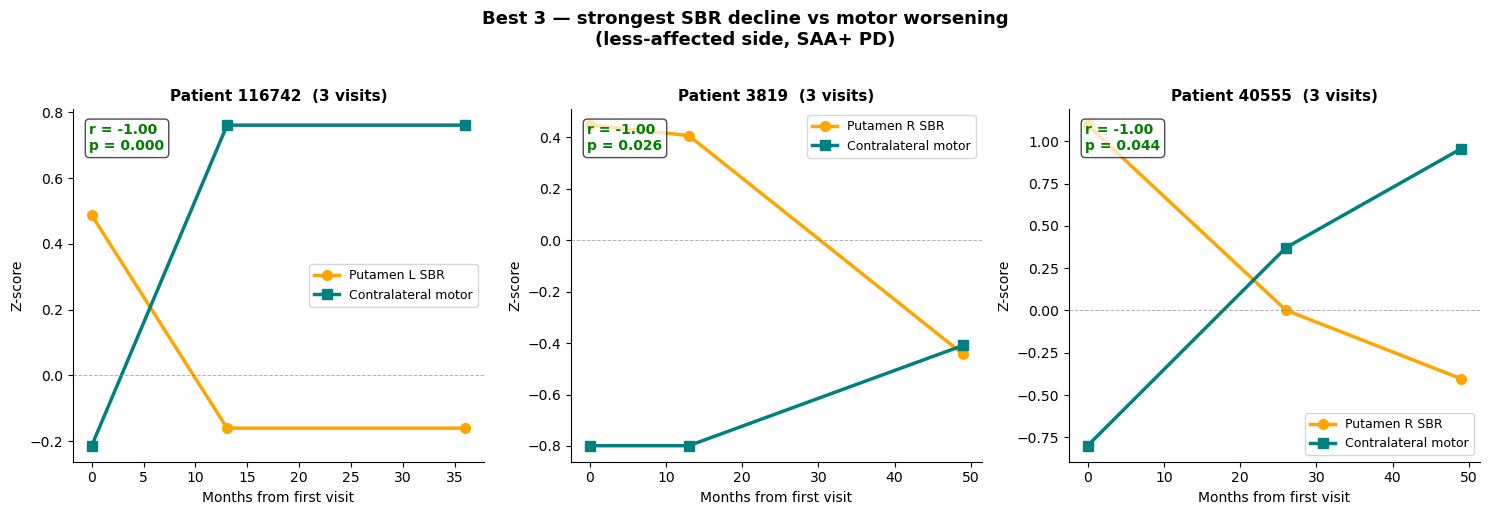

Saved: DaT_Fig_best3.png


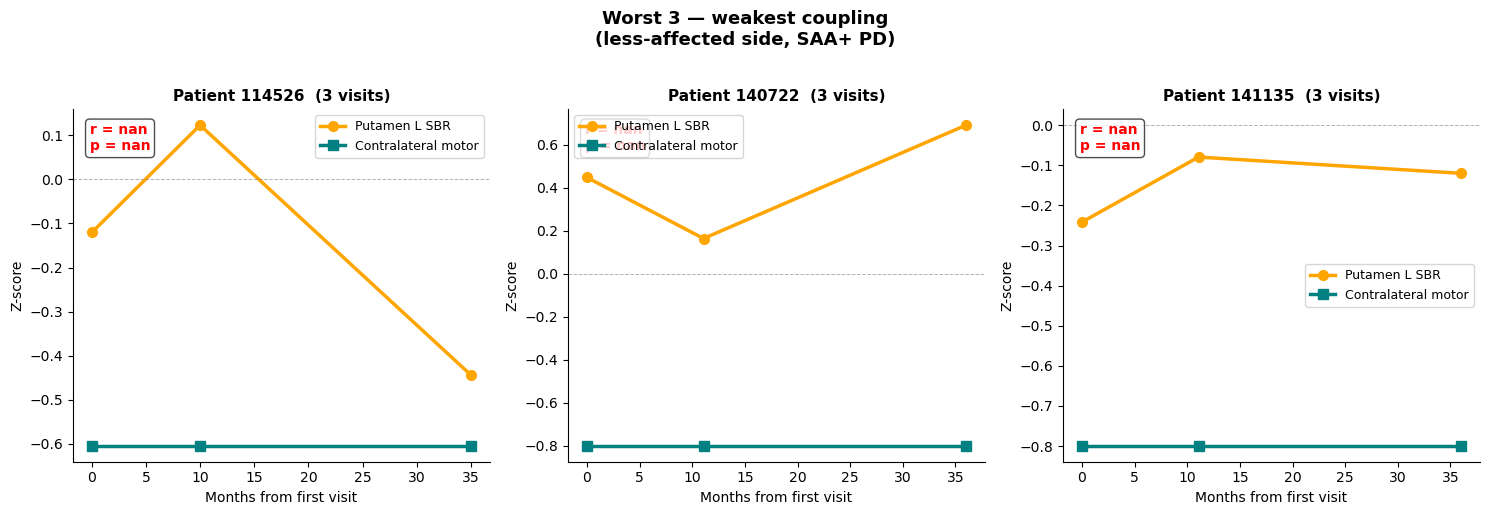

Saved: DaT_Fig_worst3.png


In [14]:
def plot_group(pat_list, title, filename):
    n = len(pat_list)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1: axes = [axes]
    for ax, pat in zip(axes, pat_list):
        sub = dfd[dfd['PATNO'] == pat].sort_values('t_months')
        t     = sub['t_months'].values
        sbr_z = sub['SBR_z'].values
        mot_z = sub['MOTOR_z'].values
        side  = sub['track_putamen'].iloc[0]

        ax.plot(t, sbr_z, color='orange', lw=2.5, marker='o', ms=7,
                label=f'Putamen {side} SBR')
        ax.plot(t, mot_z, color='teal', lw=2.5, marker='s', ms=7,
                label='Contralateral motor')
        ax.axhline(0, color='grey', lw=0.7, linestyle='--', alpha=0.6)

        r, p = scipy_stats.pearsonr(sbr_z, mot_z)
        ax.text(0.04, 0.96, f'r = {r:.2f}\np = {p:.3f}',
                transform=ax.transAxes, fontsize=10, fontweight='bold',
                color='green' if r < 0 else 'red', va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
        ax.set_title(f'Patient {pat}  ({len(sub)} visits)', fontsize=11, fontweight='bold')
        ax.set_xlabel('Months from first visit', fontsize=10)
        ax.set_ylabel('Z-score', fontsize=10)
        ax.legend(fontsize=9)
        sns.despine(ax=ax)

    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{OUT}/{filename}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

plot_group(best3,
    'Best 3 — strongest SBR decline vs motor worsening\n(less-affected side, SAA+ PD)',
    'DaT_Fig_best3.png')

plot_group(worst3,
    'Worst 3 — weakest coupling\n(less-affected side, SAA+ PD)',
    'DaT_Fig_worst3.png')

---
## Step 9 — Within-between (Mundlak) decomposition
Separates the conflated DaT-SPECT effect into:
- **within** (intra-patient): does this patient's own SBR fluctuation, relative to their own mean
  across observed visits, track their own contralateral motor score?
- **between** (inter-patient): do patients with a higher patient-specific mean SBR tend to have
  a better (lower) motor score than other patients?
- **gamma contextual** (Hausman-type test): is the difference between within and between
  estimates statistically distinguishable?

Uses raw units (`SBR_less`, `MOTOR_less`), not z-scores, so betas are directly interpretable.

In [15]:
def add_mundlak(d, var):
    g = d.groupby('PATNO')[var]
    d = d.copy()
    d[var + '_mean'] = g.transform('mean')      # BETWEEN
    d[var + '_cwc']  = d[var] - d[var + '_mean'] # WITHIN
    return d

d = dfd.dropna(subset=['MOTOR_less', 'SBR_less', 'AGE_AT_VISIT', 'SEX_bin']).copy()
d = add_mundlak(d, 'SBR_less')
n_pat, n_vis = d['PATNO'].nunique(), len(d)
print(f'Patients: {n_pat}, Visits: {n_vis}')

rows = []
def grab(res, term, label, model):
    ci = res.conf_int()
    rows.append([model, label, res.params[term], ci.loc[term,0], ci.loc[term,1],
                 res.pvalues[term], n_pat, n_vis])

r1 = smf.mixedlm('MOTOR_less ~ SBR_less + AGE_AT_VISIT + SEX_bin',
                 d, groups=d['PATNO'].astype(str), re_formula='~SBR_less').fit(method='lbfgs')
grab(r1, 'SBR_less', 'SBR (beta conflated)', 'Conflated')

r2 = smf.mixedlm('MOTOR_less ~ SBR_less_cwc + SBR_less_mean + AGE_AT_VISIT + SEX_bin',
                 d, groups=d['PATNO'].astype(str), re_formula='~SBR_less_cwc').fit(method='lbfgs')
grab(r2, 'SBR_less_cwc',  'SBR within (intra-patient)',  'Mundlak')
grab(r2, 'SBR_less_mean', 'SBR between (inter-patient)', 'Mundlak')

r3 = smf.mixedlm('MOTOR_less ~ SBR_less + SBR_less_mean + AGE_AT_VISIT + SEX_bin',
                 d, groups=d['PATNO'].astype(str), re_formula='~SBR_less').fit(method='lbfgs')
grab(r3, 'SBR_less_mean', 'gamma contextual (between - within)', 'Hausman')

res_dat = pd.DataFrame(rows, columns=['Model','Term','beta','CI_low','CI_high','p','n_pat','n_vis'])
res_dat[['beta','CI_low','CI_high']] = res_dat[['beta','CI_low','CI_high']].round(4)
res_dat['p'] = res_dat['p'].round(4)
res_dat['sig'] = np.where(res_dat['p'] < 0.05, '*', '')
pd.set_option('display.width', 160); pd.set_option('display.max_columns', None)
print(res_dat.to_string(index=False))

Patients: 230, Visits: 821
    Model                                Term     beta   CI_low  CI_high     p  n_pat  n_vis sig
Conflated                SBR (beta conflated)  -5.5935  -7.3195  -3.8675 0.000    230    821   *
  Mundlak          SBR within (intra-patient) -10.0349 -13.7993  -6.2706 0.000    230    821   *
  Mundlak         SBR between (inter-patient)  -3.7641  -5.3797  -2.1484 0.000    230    821   *
  Hausman gamma contextual (between - within)   2.9177  -0.4235   6.2588 0.087    230    821    


---
## Step 10 — Forest plot: within / between / conflated

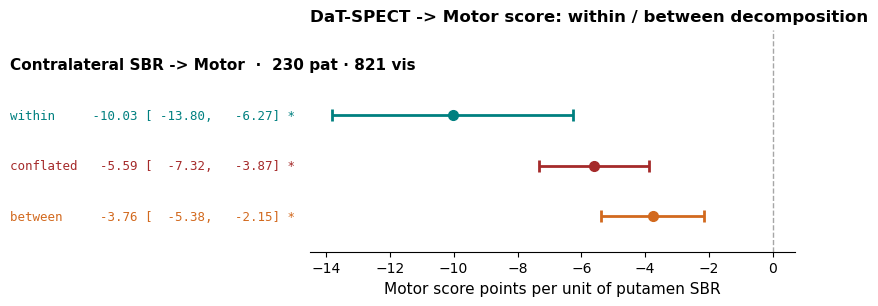

Saved: DaT_Fig_forest_within_between.png


In [16]:
CLR = {'within': 'teal', 'conflated': 'brown', 'between': 'chocolate'}

def _cat(term):
    if 'within'  in term: return 'within'
    if 'conflated' in term: return 'conflated'
    if 'between' in term and 'gamma' not in term: return 'between'
    return None

order = ['within', 'conflated', 'between']
rows = []
rows.append(('header', f'Contralateral SBR -> Motor  ·  {n_pat} pat · {n_vis} vis', None))
for c in order:
    r = res_dat[res_dat['Term'].apply(_cat) == c]
    if len(r): rows.append(('data', c, r.iloc[0]))

n = len(rows)
fig, ax = plt.subplots(figsize=(8.5, 0.5*n + 1))
ypos = list(range(n, 0, -1))

for y, (kind, label, r) in zip(ypos, rows):
    if kind == 'header':
        ax.text(-0.62, y, label, transform=ax.get_yaxis_transform(),
                ha='left', va='center', fontsize=11, fontweight='bold')
        continue
    c = label
    beta_, lo, hi, p = r['beta'], r['CI_low'], r['CI_high'], r['p']
    sig = '*' if p < 0.05 else ''
    ax.errorbar(beta_, y, xerr=[[beta_-lo], [hi-beta_]], fmt='o', ms=7,
                color=CLR[c], ecolor=CLR[c], elinewidth=2,
                capsize=4, capthick=2, zorder=3)
    ax.text(-0.62, y, f'{c:<9} {beta_:7.2f} [{lo:7.2f}, {hi:7.2f}] {sig}',
            transform=ax.get_yaxis_transform(), ha='left', va='center',
            fontsize=9, family='monospace', color=CLR[c])

ax.axvline(0, color='grey', lw=1, ls='--', alpha=0.7, zorder=1)
ax.set_yticks([])
ax.set_ylim(0.3, n + 0.7)
ax.set_xlabel('Motor score points per unit of putamen SBR', fontsize=11)
ax.set_title('DaT-SPECT -> Motor score: within / between decomposition',
             fontsize=12, fontweight='bold', loc='left')
for s in ['top','right','left']:
    ax.spines[s].set_visible(False)
plt.subplots_adjust(left=0.40, right=0.97, top=0.90, bottom=0.16)
plt.savefig(f'{OUT}/DaT_Fig_forest_within_between.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: DaT_Fig_forest_within_between.png')